---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Електронні прилади та мікроелектроніка"</h2></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Теми частини 1:</b></p>
<ul style="text-align: left;">
  <li>Зонна теорія електропровідності</li>
  <li>Власні та домішкові напівпровідники</li>
  <li>Утворення та зміщення p-n переходу</li>
  <li>Вольтамперна характеристика діода: ідеальна та реальна</li>
  <li>Тунельний та лавинний пробій</li>
  <li>Випрямні, Шотки та стабілітронні діоди</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<img src="Teacher.jpg" width="150" style="border-radius: 50%; display: block; margin: 10px auto;"/>
<p style="text-align: center;"><b>Пахалюк Богдан Петрович</b></p>
<p style="text-align: center;">Доктор філософії</p>
<p style="text-align: center;">Кафедра РТВС</p>
<hr/>
<p style="text-align: center; font-size: 0.9em;">Частина 1 з 3: Основи теоретичних положень та напівпровідникові діоди</p>
</div>
    </th>
  </tr>
</table>

---

<p style="text-align: center;"><b>Зміст</b></p>

* [Зонна теорія електропровідності. Класифікація твердих тіл](#band-theory)
* [Власні та домішкові напівпровідники](#intrinsic-doped)
* [Утворення p-n переходу. Рівноважний стан](#pn-formation)
* [p-n перехід під зовнішньою напругою](#pn-bias)
* [Ідеалізована вольтамперна характеристика діода](#ideal-iv)
* [Реальна ВАХ: пряма ділянка](#real-forward)
* [Реальна ВАХ: зворотна ділянка](#real-reverse)
* [Тунельний пробій](#tunnel-breakdown)
* [Лавинний пробій](#avalanche-breakdown)
* [Випрямні діоди. Послідовне та паралельне включення](#rectifier-diodes)
* [Діоди Шотки](#schottky-diodes)
* [Стабілітрони](#zener-diodes)

---

In [1]:
import numpy as np
import sympy as smp
import matplotlib.pyplot as plt
from matplotlib.widgets import Cursor
import matplotlib.patches as patches
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import math
from engineering_notation import EngNumber

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

q = 1.602176634e-19      # Кл, заряд електрона
k_B = 1.380649e-23       # Дж/К, стала Больцмана
T0 = 300.0               # К
phi_T = k_B*T0/q         # температурний потенціал, В
print(f"Температурний потенціал при {T0:.0f} К: φ_T = {phi_T*1000:.2f} мВ")

/home/bp/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Температурний потенціал при 300 К: φ_T = 25.85 мВ


### 🎯 Мета вивчення розділу: Зонна теорія, напівпровідники, p-n перехід

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати зонну модель твердого тіла та природу дозволених і заборонених зон енергії
> - Класифікувати тверді тіла на метали, напівпровідники та діелектрики за шириною забороненої зони
> - Розрізняти власну та домішкову (n- і p-типу) провідність напівпровідників
> - Пояснювати розташування донорних/акцепторних рівнів та роль основних і неосновних носіїв заряду
> - Описувати фізичні процеси утворення p-n переходу та його поведінку при зовнішній напрузі

</div>

### 📖 Ключові поняття

| Поняття | Визначення |
|---------|-----------|
| **Валентна зона** | Найвища за енергією зона, повністю або частково заповнена електронами при $T=0$ К |
| **Зона провідності** | Найближча вища дозволена зона, електрони якої вільно рухаються під дією поля |
| **Заборонена зона $E_g$** | Діапазон енергій, недоступних електрону в ідеальному кристалі |
| **Рівень Фермі $E_F$** | Енергія, ймовірність заповнення якої електроном дорівнює 0.5 |
| **Донор / акцептор** | Домішковий атом, що легко віддає електрон / приймає електрон (створює дірку) |

# Зонна теорія електропровідності. Класифікація твердих тіл <a class="anchor" id="band-theory"></a>

## Походження енергетичних зон

У ізольованому атомі електрони займають дискретні, чітко визначені енергетичні рівні. Коли атоми об'єднуються в кристал, їхні електронні оболонки перекриваються, і, згідно з **принципом заборони Паулі** (жодні два електрони в системі не можуть перебувати в однаковому квантовому стані), кожен дискретний рівень окремого атома розщеплюється на $N$ близько розташованих підрівнів, де $N$ — кількість атомів у кристалі (порядку $10^{22}$–$10^{23}$ см⁻³). Ці підрівні настільки близькі, що утворюють практично неперервну смугу дозволених енергій — **енергетичну зону**. Між сусідніми дозволеними зонами лишаються діапазони енергій, які електрон у ідеальному (бездефектному) кристалі приймати не може — **заборонені зони**.

Найважливішими для електропровідності є:
- **Валентна зона** — верхня із заповнених (при $T=0$ К) зон, утворена валентними електронами, що беруть участь у хімічному (ковалентному) зв'язку;
- **Зона провідності** — найближча вища дозволена зона; електрон, потрапивши туди, стає вільним носієм заряду і може набувати енергію від зовнішнього поля;
- **Заборонена зона (ширина $E_g$)** — енергетична відстань між стелею валентної зони $E_v$ та дном зони провідності $E_c$: $E_g = E_c - E_v$.

## Класифікація твердих тіл

Розподіл твердих тіл на метали, напівпровідники й діелектрики визначається **шириною забороненої зони** та **ступенем заповнення зони провідності** при робочій температурі.

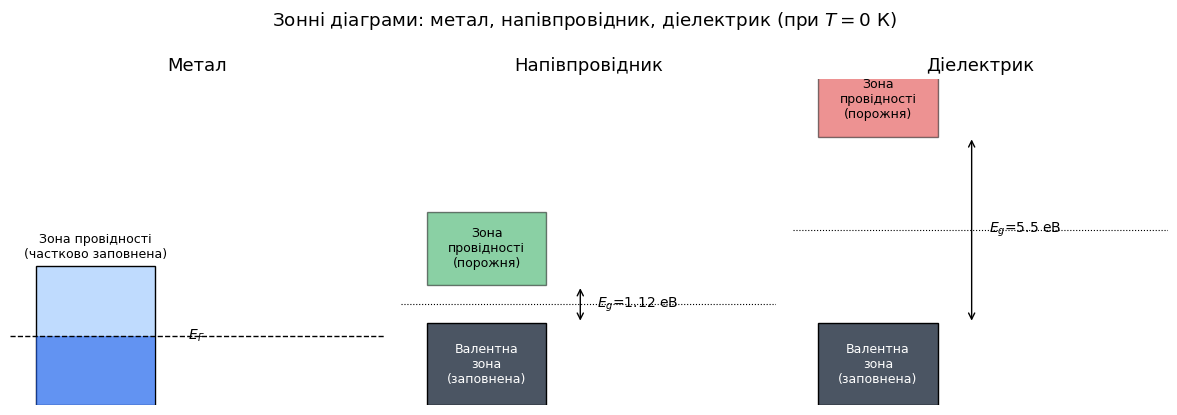

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), sharey=True)
titles = ["Метал", "Напівпровідник", "Діелектрик"]
gaps = [0.0, 1.12, 5.5]           # умовна ширина забороненої зони, еВ (перекриття для металу)
colors = ['#2563eb', '#16a34a', '#dc2626']

for ax, title, Eg, color in zip(axes, titles, gaps, colors):
    if title == "Метал":
        # частково заповнена зона провідності перекривається з валентною
        ax.add_patch(patches.Rectangle((0.15, 0.0), 0.7, 3.4, facecolor='#bfdbfe', edgecolor='k'))
        ax.add_patch(patches.Rectangle((0.15, 0.0), 0.7, 1.7, facecolor='#2563eb', edgecolor='none', alpha=0.6))
        ax.text(0.5, 3.6, "Зона провідності\n(частково заповнена)", ha='center', fontsize=9)
        ax.axhline(1.7, color='k', ls='--', lw=1)
        ax.text(1.0, 1.7, '  $E_F$', va='center', fontsize=10)
    else:
        vb_top = 2.0
        cb_bot = vb_top + Eg/1.2  # масштаб для наочності
        ax.add_patch(patches.Rectangle((0.15, 0.0), 0.7, vb_top, facecolor='#4b5563', edgecolor='k'))
        ax.add_patch(patches.Rectangle((0.15, cb_bot), 0.7, 1.8, facecolor=color, edgecolor='k', alpha=0.5))
        ax.text(0.5, vb_top/2, "Валентна\nзона\n(заповнена)", ha='center', va='center', color='white', fontsize=9)
        ax.text(0.5, cb_bot + 0.9, "Зона\nпровідності\n(порожня)", ha='center', va='center', fontsize=9)
        ax.annotate('', xy=(1.05, cb_bot), xytext=(1.05, vb_top),
                     arrowprops=dict(arrowstyle='<->', color='k'))
        ax.text(1.15, (vb_top+cb_bot)/2, f'$E_g$={Eg} еВ', va='center', fontsize=10)
        ax.axhline((vb_top+cb_bot)/2, color='k', ls=':', lw=0.8)
    ax.set_title(title)
    ax.set_xlim(0, 2.2)
    ax.set_ylim(0, 8)
    ax.axis('off')

axes[0].set_ylabel("Енергія $E$")
plt.suptitle("Зонні діаграми: метал, напівпровідник, діелектрик (при $T=0$ К)")
plt.tight_layout()
plt.show()

**Метали.** У металів зона провідності або перекривається з валентною (немає забороненої зони, $E_g=0$), або є лише частково заповненою власними валентними електронами. У будь-якому разі безпосередньо над найвищими заповненими станами завжди є вільні енергетичні стани в тій самій зоні, тому навіть нескінченно мале зовнішнє поле здатне перевести електрони у стан з ненульовою швидкістю дрейфу. Звідси — висока провідність металів ($\sigma \sim 10^6$–$10^8$ См/м), яка **зменшується** з ростом температури через посилення розсіювання електронів на теплових коливаннях ґратки (фононах).

**Діелектрики.** Заборонена зона широка ($E_g \gtrsim 3$ еВ; наприклад, алмаз — 5.5 еВ, $SiO_2$ — близько 9 еВ). При кімнатній температурі теплова енергія $kT \approx 0.026$ еВ на порядки менша за $E_g$, тому практично жоден електрон не долає заборонену зону — провідність надзвичайно мала.

**Напівпровідники.** Заборонена зона проміжна ($E_g \approx 0.1$–$3$ еВ; германій — 0.67 еВ, кремній — 1.12 еВ, арсенід галію — 1.43 еВ при 300 К). Частина електронів завдяки тепловому руху або поглинутим фотонам долає заборонену зону і переходить у зону провідності, залишаючи в валентній зоні вакантний стан — **дірку**. Головна відмінність від металу — провідність напівпровідника **зростає** з температурою (експоненційно, оскільки кількість збуджених носіїв $\propto \exp(-E_g/2kT)$), бо домінує генерація нових носіїв, а не розсіювання наявних.

### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Перший практичний напівпровідниковий прилад — детектор Брауна (1874, Карл Фердинанд Браун) — це контакт металевої голки з кристалом сульфіду свинцю чи піриту, що випрямляв струм задовго до появи зонної теорії. Пояснити, *чому* такий контакт випрямляє, вдалося лише через півстоліття, після побудови квантової теорії твердого тіла Блохом, Зоммерфельдом та Вільсоном у 1920–30-х роках.

</div>

# Власні і домішкові напівпровідники <a class="anchor" id="intrinsic-doped"></a>

## Власна (внутрішня) провідність

**Власним (внутрішнім)** називають хімічно чистий напівпровідник без домішок. Єдине джерело носіїв заряду — теплова генерація: електрон валентної зони, отримавши енергію $\ge E_g$, переходить у зону провідності, залишаючи дірку. Оскільки кожен акт генерації одночасно створює електрон і дірку,

$$n_i = p_i, \qquad n_i(T) = A\, T^{3/2} \exp\!\left(-\dfrac{E_g}{2kT}\right),$$

де $n_i$ — власна концентрація носіїв (для кремнію при 300 К $n_i \approx 1.5\times10^{10}$ см⁻³). Рівень Фермі власного напівпровідника лежить практично посередині забороненої зони.

## Домішкова провідність

Введення в кристалічну ґратку домішкових атомів (**легування**) на 5–6 порядків підвищує концентрацію носіїв одного знаку, практично не змінюючи концентрацію носіїв іншого знаку — такий напівпровідник називають **домішковим (екстринсивним)**.

**Донорна домішка (n-тип).** Атом V групи (P, As, Sb) у ґратці кремнію (IV група) має один "зайвий" валентний електрон, не потрібний для ковалентних зв'язків. Цей електрон слабко зв'язаний з атомом (енергія іонізації $E_c - E_d \approx 0.01$–$0.05$ еВ — набагато менша за $E_g$) і при кімнатній температурі майже завжди відривається в зону провідності, залишаючи нерухомий позитивно заряджений іон донора. Основні носії — електрони, неосновні — дірки.

**Акцепторна домішка (p-тип).** Атом III групи (B, Al, Ga, In) має на один валентний електрон менше, ніж потрібно для зв'язків із сусідами. Він захоплює електрон із валентної зони (акцепторний рівень $E_a - E_v$ близько до $E_v$), утворюючи рухому дірку і нерухомий негативно заряджений іон акцептора. Основні носії — дірки, неосновні — електрони.

Незалежно від рівня легування в стані термодинамічної рівноваги виконується **закон діючих мас**:

$$n \cdot p = n_i^2,$$

тому в напівпровіднику n-типу з концентрацією донорів $N_d \gg n_i$: $n_0 \approx N_d$, а $p_0 = n_i^2/N_d \ll n_0$ (аналогічно для p-типу).

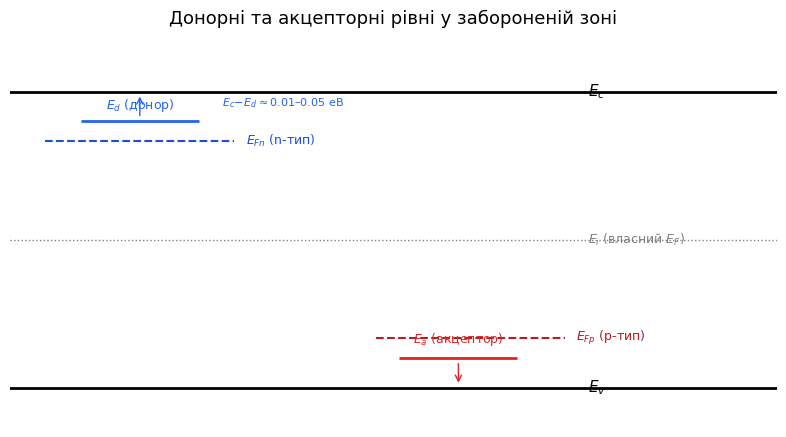

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
Ec, Ev = 3.0, 0.0
ax.axhline(Ec, color='k', lw=2); ax.text(4.6, Ec, '$E_c$', va='center')
ax.axhline(Ev, color='k', lw=2); ax.text(4.6, Ev, '$E_v$', va='center')
ax.axhline((Ec+Ev)/2, color='gray', ls=':', lw=1)
ax.text(4.6, (Ec+Ev)/2, '$E_i$ (власний $E_F$)', va='center', color='gray', fontsize=9)

# донорний рівень
Ed = Ec - 0.3
ax.hlines(Ed, 0.3, 1.3, color='#2563eb', lw=2)
ax.text(0.8, Ed+0.12, '$E_d$ (донор)', ha='center', color='#2563eb', fontsize=9)
ax.annotate('', xy=(0.8, Ec-0.02), xytext=(0.8, Ed+0.03), arrowprops=dict(arrowstyle='->', color='#2563eb'))
ax.text(1.5, (Ed+Ec)/2, r"$E_c\!-\!E_d\approx$0.01–0.05 еВ", fontsize=8, color='#2563eb')
efn = Ec - 0.5
ax.hlines(efn, 0.0, 1.6, color='#1d4ed8', lw=1.5, linestyles='--')
ax.text(1.7, efn, '$E_{Fn}$ (n-тип)', va='center', color='#1d4ed8', fontsize=9)

# акцепторний рівень
Ea = Ev + 0.3
ax.hlines(Ea, 3.0, 4.0, color='#dc2626', lw=2)
ax.text(3.5, Ea+0.15, '$E_a$ (акцептор)', ha='center', color='#dc2626', fontsize=9)
ax.annotate('', xy=(3.5, Ev+0.02), xytext=(3.5, Ea-0.03), arrowprops=dict(arrowstyle='->', color='#dc2626'))
efp = Ev + 0.5
ax.hlines(efp, 2.8, 4.4, color='#b91c1c', lw=1.5, linestyles='--')
ax.text(4.5, efp, '$E_{Fp}$ (p-тип)', va='center', color='#b91c1c', fontsize=9)

ax.set_xlim(-0.3, 6.2); ax.set_ylim(-0.4, 3.6)
ax.axis('off')
ax.set_title('Донорні та акцепторні рівні у забороненій зоні')
plt.tight_layout(); plt.show()

### ✅ Питання для самоперевірки: Зонна теорія та напівпровідники

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому провідність металу зменшується з температурою, а провідність напівпровідника — зростає?</summary>

> **Відповідь:** У металі носіїв завжди достатньо (частково заповнена зона), і з ростом $T$ посилюється лише розсіювання на фононах, що зменшує рухливість і провідність. У напівпровіднику з ростом $T$ експоненційно зростає кількість носіїв, згенерованих через заборонену зону, і цей ефект переважає над зменшенням рухливості.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чи може концентрація неосновних носіїв у сильно легованому напівпровіднику перевищувати $n_i$?</summary>

> **Відповідь:** Ні, вона завжди менша за $n_i$: за законом діючих мас $n\cdot p = n_i^2$, тому в n-типі $p_0 = n_i^2/N_d \ll n_i$, оскільки $N_d \gg n_i$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому енергія іонізації донора (0.01–0.05 еВ) набагато менша за ширину забороненої зони кремнію (1.12 еВ)?</summary>

> **Відповідь:** Зайвий електрон донора рухається в кулонівському полі іона донора, екранованого діелектричною проникністю ґратки (для Si $\varepsilon_r\approx11.7$), що за моделлю, аналогічною атому водню, зменшує енергію зв'язку пропорційно $1/\varepsilon_r^2$ — до сотих часток еВ.

</details>


# Утворення p-n переходу. Процеси при нульовому зміщенні <a class="anchor" id="pn-formation"></a>

**p-n перехід** — це область контакту двох областей одного й того ж монокристала напівпровідника з різним типом провідності (p та n), отримана технологічно (наприклад, дифузією або іонною імплантацією донорної домішки в підкладку p-типу, або навпаки).

## Дифузійна стадія

У момент утворення переходу на межі існує різкий перепад концентрацій: у n-області багато вільних електронів і мало дірок, у p-області — навпаки. Під дією градієнта концентрації відбувається **дифузія основних носіїв** назустріч один одному: електрони дифундують з n- в p-область, дірки — з p- в n-область.

Носії, що пішли, залишають після себе **нескомпенсовані нерухомі іони домішок**: у приграничному шарі n-області — позитивні іони донорів, у p-області — негативні іони акцепторів. Оскільки рухомих носіїв в цьому шарі майже не залишається, його називають **шаром об'ємного заряду (ЗЗ)**, або **збідненим шаром**.

## Рівновага: дрейф врівноважує дифузію

Об'ємний заряд іонів створює внутрішнє електричне поле $E_{вн}$, спрямоване від n- до p-області (від "+" до "–"). Це поле:
- гальмує подальшу дифузію основних носіїв (перешкоджає їх руху проти поля);
- прискорює неосновні носії, що потрапляють у збіднений шар (дрейфовий струм у напрямку, протилежному дифузійному).

Рівновага настає, коли дифузійний і дрейфовий струми для кожного типу носіїв компенсують один одного, а результуючий струм через перехід дорівнює нулю. Цій рівновазі відповідає **контактна різниця потенціалів (потенціальний бар'єр)**:

$$\varphi_k = \varphi_T \ln\frac{N_a N_d}{n_i^2}, \qquad \varphi_T = \frac{kT}{q}$$

(для кремнію за типових концентрацій легування $\varphi_k \approx 0.6$–$0.8$ В).

На зонній діаграмі рівновага виявляється у вигляді **вигину зон**: рівень Фермі по всій структурі — єдина горизонтальна лінія (умова термодинамічної рівноваги), а зони провідності й валентні зони плавно "перегинаються" на висоту $q\varphi_k$ в області переходу.

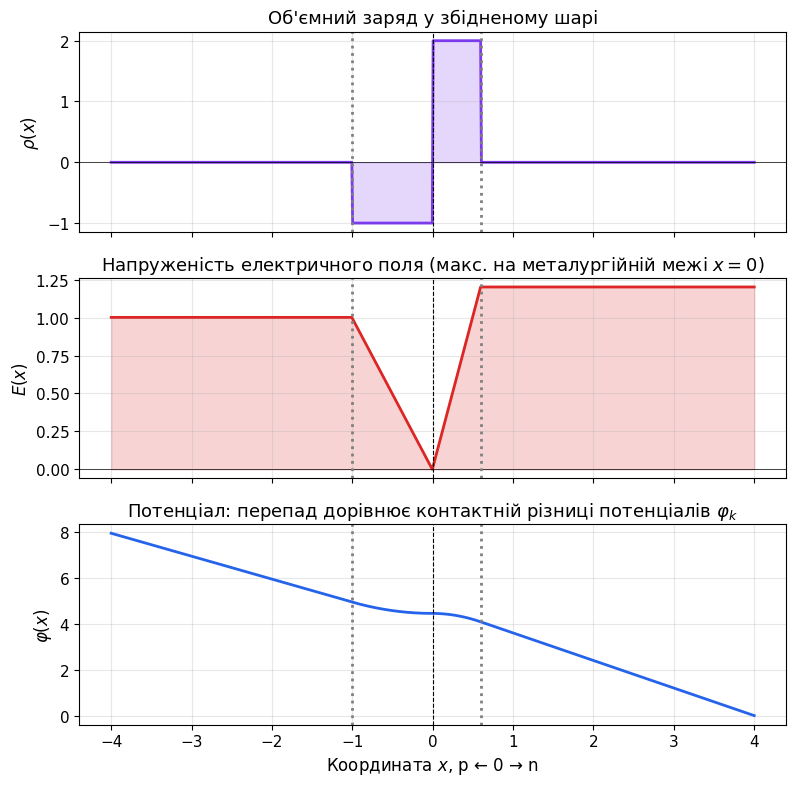

In [4]:
x = np.linspace(-4, 4, 800)
Na, Nd = 1.0, 2.0          # умовні концентрації (Na<Nd -> вужча область в p при більшій Nd)
xp, xn = -1.0, 0.6         # межі збідненого шару (умовно, Na*xp = Nd*xn для нейтральності)

def step_field(x, xp, xn, Na, Nd):
    rho = np.where((x>=xp)&(x<0), -Na, 0.0) + np.where((x>=0)&(x<=xn), Nd, 0.0)
    return rho

rho = step_field(x, xp, xn, Na, Nd)
E = -np.cumsum(rho)*(x[1]-x[0])
E -= E.min()
E = -(E - E.max())  # напрямок поля від n до p (від'ємне значення за віссю x)
phi = -np.cumsum(E)*(x[1]-x[0])
phi -= phi.min()

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
axes[0].plot(x, rho, color='#7c3aed'); axes[0].axhline(0, color='k', lw=0.5)
axes[0].fill_between(x, rho, 0, alpha=0.2, color='#7c3aed')
axes[0].set_ylabel(r'$\rho(x)$'); axes[0].set_title('Об\'ємний заряд у збідненому шарі')

axes[1].plot(x, E, color='#dc2626'); axes[1].axhline(0, color='k', lw=0.5)
axes[1].fill_between(x, E, 0, alpha=0.2, color='#dc2626')
axes[1].set_ylabel(r'$E(x)$'); axes[1].set_title('Напруженість електричного поля (макс. на металургійній межі $x=0$)')

axes[2].plot(x, phi, color='#2563eb')
axes[2].set_ylabel(r'$\varphi(x)$'); axes[2].set_xlabel('Координата $x$, p ← 0 → n')
axes[2].set_title(r'Потенціал: перепад дорівнює контактній різниці потенціалів $\varphi_k$')

for ax in axes:
    ax.axvline(xp, color='gray', ls=':'); ax.axvline(xn, color='gray', ls=':')
    ax.axvline(0, color='k', ls='--', lw=0.8)
plt.tight_layout(); plt.show()

**Ширина збідненого шару.** З умови електронейтральності ($N_a x_p = N_d x_n$, заряд іонізованих акцепторів дорівнює заряду іонізованих донорів) та розв'язку рівняння Пуассона отримують:

$$W = x_n + x_p = \sqrt{\dfrac{2\varepsilon_s}{q}\left(\dfrac{1}{N_a}+\dfrac{1}{N_d}\right)\varphi_k}$$

Перехід "заглиблюється" сильніше в бік **менш легованої** області (щоб зберегти баланс зарядів при меншій концентрації іонів на одиницю об'єму там потрібен товщий шар).

# Процеси в p-n переході під впливом зовнішньої напруги <a class="anchor" id="pn-bias"></a>

## Пряме зміщення ($+$ на p, $-$ на n)

Зовнішнє поле напрямлене назустріч внутрішньому полю $E_{вн}$, тому результуюче поле в переході слабшає: висота потенціального бар'єра зменшується до $\varphi_k - U$, а ширина збідненого шару звужується. Це різко полегшує дифузію основних носіїв — електрони масово **інжектуються** з n- в p-область (де стають неосновними), дірки — з p- в n-область. Інжектовані неосновні носії дифундують углиб нейтральної області та рекомбінують, підтримуючи великий прямий струм, що **експоненційно** зростає з напругою.

## Зворотне зміщення ($-$ на p, $+$ на n)

Зовнішнє поле збігається з напрямком $E_{вн}$: бар'єр зростає до $\varphi_k + U$, збіднений шар розширюється (приблизно $\propto\sqrt{\varphi_k+U}$). Дифузія основних носіїв практично повністю пригнічується. Через перехід тече лише малий **дрейфовий струм неосновних носіїв** — електронів, що термогенеруються в p-області і дірок з n-області, які "скочуються" полем переходу. Цей струм майже не залежить від прикладеної напруги (обмежений швидкістю теплової генерації, а не полем) — звідси назва **зворотний струм насичення** $I_S$.

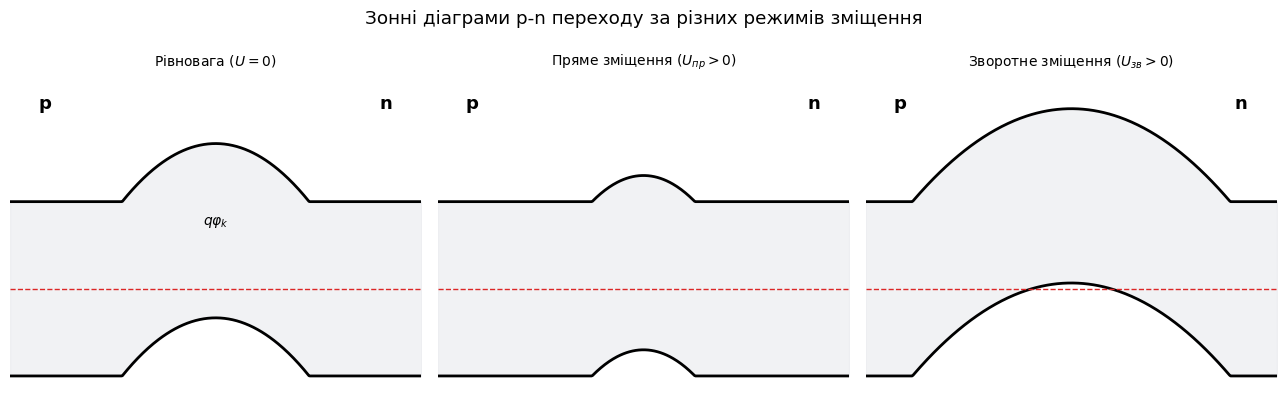

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
labels = ['Рівновага ($U=0$)', 'Пряме зміщення ($U_{пр}>0$)', 'Зворотне зміщення ($U_{зв}>0$)']
barrier_h = [1.0, 0.45, 1.6]
widths = [1.0, 0.55, 1.7]

for ax, label, h, w in zip(axes, labels, barrier_h, widths):
    xs = np.linspace(-2.2, 2.2, 400)
    Ec = np.where(np.abs(xs) < w, 3.0 + h*(1-(xs/w)**2)*(np.abs(xs)<w), 3.0)
    Ec = 3.0 + h*np.clip(1-(xs/w)**2, 0, None)
    Ev = Ec - 3.0
    ax.plot(xs, Ec, color='k', lw=2)
    ax.plot(xs, Ev, color='k', lw=2)
    ax.fill_between(xs, Ev, Ec, color='#e5e7eb', alpha=0.5)
    ax.axhline(1.5, color='#dc2626', ls='--', lw=1)
    ax.set_title(label, fontsize=10)
    ax.set_xlim(-2.2, 2.2); ax.set_ylim(-0.5, 5.2)
    ax.text(-1.9, 4.6, 'p', fontsize=13, fontweight='bold')
    ax.text(1.75, 4.6, 'n', fontsize=13, fontweight='bold')
    ax.axis('off')

axes[0].text(0, 2.6, r'$q\varphi_k$', ha='center', fontsize=10)
plt.suptitle('Зонні діаграми p-n переходу за різних режимів зміщення')
plt.tight_layout(); plt.show()

### ✅ Питання для самоперевірки: p-n перехід

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому в рівноважному p-n переході, попри наявність контактної різниці потенціалів, струм через нього дорівнює нулю?</summary>

> **Відповідь:** Тому що дифузійна складова струму (основні носії, що долають бар'єр за рахунок теплового розподілу енергій) і дрейфова складова (неосновні носії, що потрапляють у збіднений шар і зносяться полем) для кожного типу носіїв точно компенсують одна одну — це умова динамічної рівноваги, а не відсутності руху носіїв узагалі.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому при зворотному зміщенні струм майже не залежить від напруги, а при прямому — залежить експоненційно?</summary>

> **Відповідь:** При зворотному зміщенні струм визначається швидкістю термогенерації неосновних носіїв поблизу переходу (процес, що не залежить від висоти бар'єра, поки той є), тоді як при прямому зміщенні висота бар'єра $q(\varphi_k-U)$ входить в експоненту розподілу Больцмана, що визначає частку основних носіїв, здатних його подолати.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> В який бік — до більш чи менш легованої області — зміщується межа збідненого шару найбільше при зміні напруги?</summary>

> **Відповідь:** Збіднений шар завжди ширший з боку менш легованої області (там менша концентрація нерухомих іонів, тож для того самого заряду потрібен більший об'єм), і саме ця частина найсильніше змінює свою протяжність при зміні зовнішньої напруги.

</details>


### 🎯 Мета вивчення розділу: Вольтамперна характеристика та пробій p-n переходу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Записувати та пояснювати рівняння Шоклі для ідеалізованої ВАХ діода
> - Пояснювати причини відхилення реальної ВАХ від ідеальної на прямій ділянці (рекомбінація, опір бази)
> - Пояснювати причини відхилення реальної ВАХ від ідеальної на зворотній ділянці (поверхневі струми, термогенерація, пробій)
> - Розрізняти фізичні механізми тунельного та лавинного пробою та їх температурні коефіцієнти

</div>

# Ідеалізована вольтамперна характеристика діода <a class="anchor" id="ideal-iv"></a>

Ідеалізована модель p-n переходу (модель Шоклі) нехтує генерацією-рекомбінацією в самому збідненому шарі, опором нейтральних областей та поверхневими ефектами, розглядаючи лише дифузію інжектованих неосновних носіїв. Результат — рівняння **ідеального діода (рівняння Шоклі)**:

$$I = I_S\left(\exp\!\frac{U}{\varphi_T} - 1\right), \qquad \varphi_T = \frac{kT}{q}\approx 25.85\text{ мВ при }300\text{ К}$$

де $I_S$ — **тепловий (зворотний) струм насичення**, що визначається властивостями напівпровідника (коефіцієнтами дифузії, часом життя неосновних носіїв, площею переходу, концентраціями легування) і сильно залежить від температури ($I_S \propto n_i^2 \propto \exp(-E_g/kT)$), але не залежить від прикладеної напруги.

- При **прямій напрузі** ($U>0$, $U\gg\varphi_T$) експонента домінує: $I\approx I_S e^{U/\varphi_T}$ — струм зростає експоненційно, практично необмежено (в ідеальній моделі).
- При **зворотній напрузі** ($U<0$, $|U|\gg\varphi_T$) експонента прямує до нуля: $I \to -I_S$ — струм виходить на постійне (насичене) значення, що не залежить від напруги.

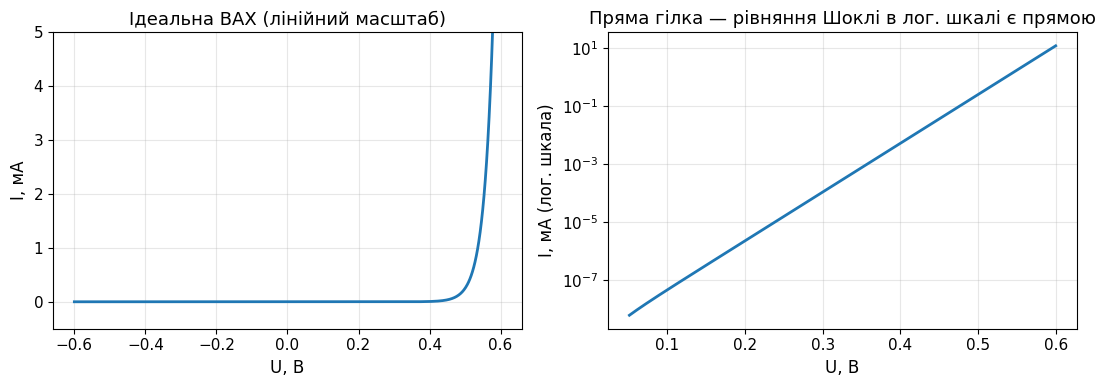

interactive(children=(FloatLogSlider(value=1.0, description='$I_S$, пА', max=2.0, min=-2.0), FloatSlider(value…

In [6]:
Is = 1e-12   # А, умовний струм насичення
n_ideal = 1.0
U = np.linspace(-0.6, 0.6, 1000)
I = Is*(np.exp(U/(n_ideal*phi_T)) - 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(U, I*1e3)
axes[0].set_xlabel('U, В'); axes[0].set_ylabel('I, мА')
axes[0].set_title('Ідеальна ВАХ (лінійний масштаб)')
axes[0].set_ylim(-0.5, 5)

axes[1].semilogy(U[U>0.05], np.abs(I[U>0.05])*1e3)
axes[1].set_xlabel('U, В'); axes[1].set_ylabel('I, мА (лог. шкала)')
axes[1].set_title('Пряма гілка — рівняння Шоклі в лог. шкалі є прямою')
plt.tight_layout(); plt.show()

def plot_ideal_diode(Is_pA=1.0, n=1.0):
    Is_ = Is_pA*1e-12
    U_ = np.linspace(-0.6, 0.6, 1000)
    I_ = Is_*(np.exp(U_/(n*phi_T)) - 1)
    plt.figure(figsize=(6,4))
    plt.plot(U_, I_*1e3)
    plt.xlabel('U, В'); plt.ylabel('I, мА')
    plt.title(f'$I_S$={Is_pA:.2f} пА, n={n:.2f}')
    plt.ylim(-0.5, 5)
    plt.show()

w = interactive(plot_ideal_diode,
                 Is_pA=widgets.FloatLogSlider(value=1.0, base=10, min=-2, max=2, description='$I_S$, пА'),
                 n=widgets.FloatSlider(value=1.0, min=1.0, max=2.0, step=0.05, description='n'))
display(w)

# Відмінність реальної ВАХ від ідеальної: пряма ділянка <a class="anchor" id="real-forward"></a>

Реальний діод відхиляється від рівняння Шоклі на прямій гілці з двох основних причин.

**1. Генерація-рекомбінація в самому переході (при малих струмах).** Модель Шоклі не враховує рекомбінацію носіїв безпосередньо в збідненому шарі. Цей додатковий струм рекомбінації описується тим самим виглядом експоненти, але з **коефіцієнтом неідеальності** $n\approx2$ замість $n=1$:

$$I \approx I_{S2}\exp\!\frac{U}{2\varphi_T}$$

При малих прямих струмах ($U$ до ~0.4–0.5 В для Si) рекомбінаційна складова переважає, і нахил ВАХ у логарифмічному масштабі відповідає $n\approx2$; при середніх струмах переважає дифузійна складова Шоклі ($n\approx1$).

**2. Падіння напруги на послідовному (об'ємному) опорі при великих струмах.** Реальний кристал має ненульовий опір нейтральних областей і контактів $R_s$. Прикладена напруга розподіляється: $U = U_{перех} + I R_s$, де лише $U_{перех}$ керує експоненційним струмом переходу. При великих струмах падіння $IR_s$ стає порівнянним, а потім і більшим за $U_{перех}$ — крива "загинається" й переходить у майже лінійну ділянку, що визначається опором $R_s$, а не експонентою.

2026-09-21 10:53:13,897 - PySpice.Spice.NgSpice.Shared.NgSpiceShared._init_ngspice - WARNING - Unsupported Ngspice version 42


2026-09-21 10:53:13,918 - PySpice.Spice.NgSpice.Shared.NgSpiceShared._send_char - WARNING - Using SPARSE 1.3 as Direct Linear Solver


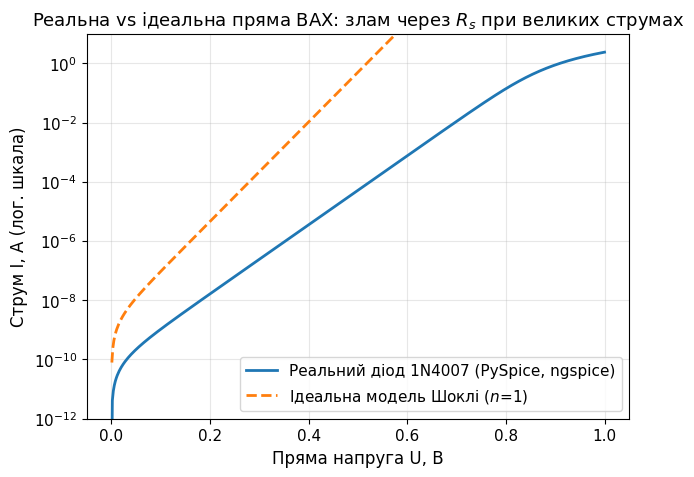

In [7]:
circuit = Circuit('Diode forward IV')
circuit.include('1N4007.mod')
circuit.V('in', 'anode', circuit.gnd, 0@u_V)
circuit.D('D1', 'anode', circuit.gnd, model='DI_1N4007')

simulator = circuit.simulator(temperature=25, nominal_temperature=25)
analysis = simulator.dc(Vin=slice(0, 1.0, 0.002))

Ureal = np.array(analysis.sweep)
Ireal = -np.array(analysis['Vin'])  # струм джерела (від'ємний за конвенцією PySpice)

Uideal = np.linspace(0.001, 1.0, 500)
Is_fit = 2e-9
Iideal = Is_fit*(np.exp(Uideal/phi_T)-1)

plt.figure(figsize=(7,5))
plt.semilogy(Ureal, np.clip(Ireal,1e-15,None), label='Реальний діод 1N4007 (PySpice, ngspice)')
plt.semilogy(Uideal, Iideal, '--', label='Ідеальна модель Шоклі ($n$=1)')
plt.xlabel('Пряма напруга U, В'); plt.ylabel('Струм I, А (лог. шкала)')
plt.title('Реальна vs ідеальна пряма ВАХ: злам через $R_s$ при великих струмах')
plt.legend(); plt.ylim(1e-12, 10)
plt.show()

### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Багато студентів вважають, що спад напруги на кремнієвому діоді — це фіксована стала $\approx 0.6$–$0.7$ В за **будь-якого** струму. Насправді ця величина є наближенням лише для типового робочого діапазону струмів. Через логарифмічну залежність $U\approx\varphi_T\ln(I/I_S)$ при малих струмах (мкА і менше) спад напруги значно нижчий, а при великих струмах (одиниці ампер) домінує $IR_s$ — падіння напруги зростає майже **лінійно** зі струмом, а не логарифмічно. Використання константи "0.7 В" для оцінки потужності при великих струмах призводить до суттєвої похибки.

</div>

# Відмінність реальної ВАХ від ідеальної: зворотна ділянка <a class="anchor" id="real-reverse"></a>

Ідеальна модель передбачає постійний зворотний струм $I_S$, що не залежить від напруги. У реальному діоді зворотний струм відхиляється від цього з кількох причин:

1. **Термогенераційний струм у збідненому шарі.** Крім дифузійного струму $I_S$ (генерація в нейтральних областях, що дифундує до переходу), існує струм генерації носіїв **у самому** збідненому шарі. Він пропорційний ширині шару $W$, яка зростає зі зворотною напругою ($W\propto\sqrt{\varphi_k+|U|}$), тому реальний зворотний струм повільно **зростає** з ростом $|U|$, а не залишається постійним.
2. **Поверхневі струми витоку.** Уздовж поверхні кристала (межа розділу з пасивуючим оксидом чи корпусом) існують додаткові шляхи витоку заряду, чутливі до забруднень і вологи; вони також збільшують реальний зворотний струм понад ідеальне значення.
3. **Пробій при досягненні критичної напруги.** При зворотній напрузі, що перевищує напругу пробою $U_{BR}$ (тунельний або лавинний механізм — див. далі), струм різко зростає — це вже принципово інший режим, не описаний рівнянням Шоклі.

Крім того, зворотний струм **значно сильніше залежить від температури**, ніж прямий: оскільки він визначається тепловою генерацією носіїв, для кремнієвих діодів він приблизно **подвоюється кожні 8–10 °C**.

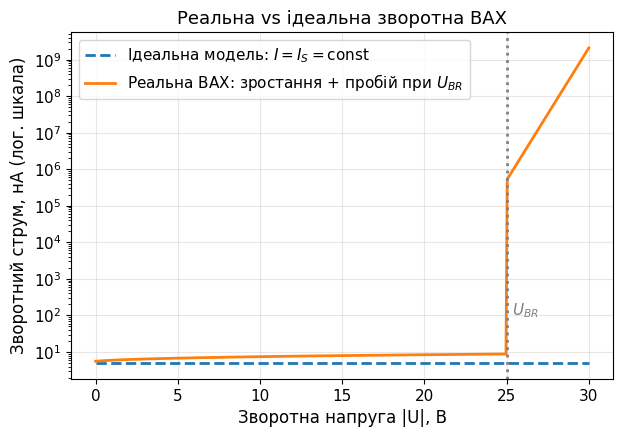

In [8]:
U_r = np.linspace(0, 30, 400)
Is0 = 5e-9
I_ideal_r = np.full_like(U_r, Is0)
I_real_r = Is0*(1 + 0.15*np.sqrt(U_r+0.6))   # зростання через термогенерацію в ЗЗ
U_BR = 25.0
I_breakdown = np.where(U_r < U_BR, I_real_r, I_real_r + 5e-4*np.exp((U_r-U_BR)/0.6))

plt.figure(figsize=(7,4.5))
plt.semilogy(U_r, I_ideal_r*1e9, '--', label='Ідеальна модель: $I=I_S=$const')
plt.semilogy(U_r, I_breakdown*1e9, label='Реальна ВАХ: зростання + пробій при $U_{BR}$')
plt.axvline(U_BR, color='gray', ls=':')
plt.text(U_BR+0.3, 1e2, '$U_{BR}$', color='gray')
plt.xlabel('Зворотна напруга |U|, В'); plt.ylabel('Зворотний струм, нА (лог. шкала)')
plt.title('Реальна vs ідеальна зворотна ВАХ')
plt.legend(); plt.show()

# Тунельний пробій <a class="anchor" id="tunnel-breakdown"></a>

**Тунельний (зенерівський) пробій** виникає у **сильнолегованих** ($N_a, N_d \gtrsim 10^{18}$–$10^{19}$ см⁻³) переходах, де збіднений шар надзвичайно вузький (одиниці нанометрів). При достатній зворотній напрузі енергетичні зони викривляються настільки, що заповнені стани валентної зони p-області опиняються **на тому ж енергетичному рівні**, що й вільні стани зони провідності n-області, розділені лише вузьким потенціальним бар'єром.

Електрон здатний **квантовомеханічно тунелювати** крізь цей бар'єр без зміни енергії (не долаючи його "згори", а проходячи "наскрізь") — це чисто квантовий ефект, ймовірність якого експоненційно залежить від ширини й висоти бар'єра. Оскільки бар'єр украй вузький, ймовірність тунелювання значна вже за помірних зворотних напруг.

**Ознаки і властивості:**
- Різкий, добре відтворюваний злам ВАХ, зазвичай при напругах **до ~5–6 В** для кремнію;
- **Від'ємний температурний коефіцієнт** напруги пробою: з ростом $T$ ширина забороненої зони $E_g$ незначно **зменшується**, а розподіл електронів у валентній зоні "розмивається" в бік вищих енергій — обидва ефекти полегшують тунелювання, тому напруга, за якої настає помітний тунельний струм, **знижується** з температурою.
- Лежить в основі роботи низьковольтних стабілітронів (< 5–6 В) і **тунельних діодів (діодів Есакі)**, у яких через ще вищий рівень легування тунельний струм спостерігається вже за **прямого** зміщення, створюючи характерну ділянку з **від'ємним диференціальним опором**.

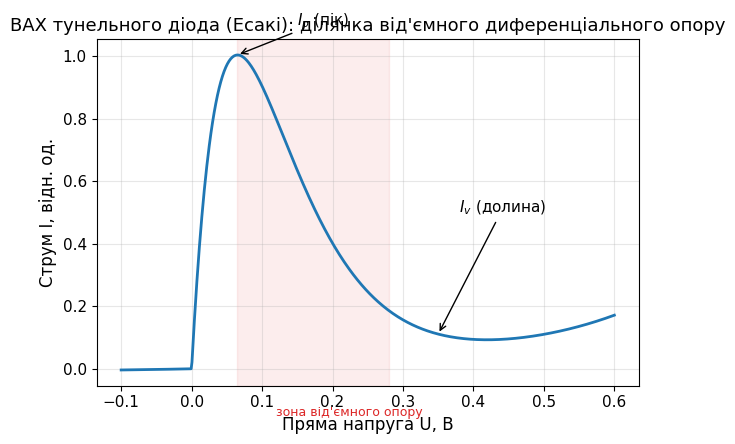

interactive(children=(FloatSlider(value=1.0, description='$I_p$', max=2.0, min=0.3), FloatSlider(value=0.065, …

In [9]:
def tunnel_diode_iv(U, Ip=1.0, Vp=0.065, Iv=0.1, Vv=0.35, Is=0.01, n=8):
    # Спрощена емпірична модель Esaki: тунельна компонента (з піком) + звичайна дифузійна
    I_tunnel = Ip * (U/Vp) * np.exp(1 - U/Vp)
    I_tunnel = np.clip(I_tunnel, 0, None)
    I_diode = Is*(np.exp(U/(n*0.026)) - 1)
    return I_tunnel + I_diode

U = np.linspace(-0.1, 0.6, 600)
I = tunnel_diode_iv(U)

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(U, I)
ax.set_xlabel('Пряма напруга U, В'); ax.set_ylabel('Струм I, відн. од.')
ax.set_title('ВАХ тунельного діода (Есакі): ділянка від\'ємного диференціального опору')
ax.annotate('$I_p$ (пік)', xy=(0.065, tunnel_diode_iv(np.array([0.065]))[0]), xytext=(0.15, 1.1),
            arrowprops=dict(arrowstyle='->'))
ax.annotate('$I_v$ (долина)', xy=(0.35, tunnel_diode_iv(np.array([0.35]))[0]), xytext=(0.38, 0.5),
            arrowprops=dict(arrowstyle='->'))
ax.axvspan(0.065, 0.28, color='#dc2626', alpha=0.08)
ax.text(0.12, -0.15, 'зона від\'ємного опору', color='#dc2626', fontsize=9)
plt.show()

def plot_tunnel(Ip=1.0, Vp=0.065, Iv=0.1, Vv=0.35):
    U_ = np.linspace(-0.05, 0.6, 400)
    I_ = tunnel_diode_iv(U_, Ip=Ip, Vp=Vp, Iv=Iv, Vv=Vv)
    plt.figure(figsize=(6,4))
    plt.plot(U_, I_)
    plt.xlabel('U, В'); plt.ylabel('I, відн.од.')
    plt.title(f'Ip={Ip:.2f}, Vp={Vp:.3f} В')
    plt.show()

w = interactive(plot_tunnel,
                 Ip=widgets.FloatSlider(value=1.0, min=0.3, max=2.0, step=0.1, description='$I_p$'),
                 Vp=widgets.FloatSlider(value=0.065, min=0.03, max=0.15, step=0.005, description='$V_p$, В'),
                 Iv=fixed(0.1), Vv=fixed(0.35))
display(w)

# Лавинний пробій <a class="anchor" id="avalanche-breakdown"></a>

**Лавинний пробій** переважає в переходах з **помірним або низьким рівнем легування**, де збіднений шар відносно широкий. Неосновні носії (електрони й дірки), що потрапляють у збіднений шар, розганяються сильним електричним полем на довжині вільного пробігу до кінетичної енергії, достатньої для **ударної іонізації**: зіткнення з атомом ґратки розриває ковалентний зв'язок, народжуючи нову пару електрон-дірка. Обидва нові носії, своєю чергою, теж розганяються полем і спричиняють подальшу іонізацію — виникає **лавинне розмноження носіїв** (коефіцієнт лавинного множення $M\to\infty$ при $U\to U_{BR}$), і струм різко, майже стрибком, зростає.

**Ознаки і властивості:**
- Напруга пробою зазвичай **вища** (типово > 6–7 В для кремнію) і зростає при зменшенні концентрації легування (ширший перехід — довший шлях розгону носіїв, потрібне менше поле для набору тієї ж енергії, але оскільки поле $E=\Delta\varphi/W$, для товщого переходу потрібна вища сумарна напруга для досягнення критичного поля);
- **Додатний температурний коефіцієнт**: з ростом $T$ посилюється розсіювання носіїв на теплових коливаннях ґратки (фонон-носійна взаємодія), тому середня довжина вільного пробігу між зіткненнями **скорочується** — носію потрібне сильніше поле (а отже й вища напруга), щоб набрати енергію, достатню для ударної іонізації між зіткненнями. Тому $U_{BR}$ **зростає** з температурою.
- Лежить в основі роботи високовольтних стабілітронів (> 6–7 В), лавинних фотодіодів, а також визначає граничну зворотну напругу звичайних випрямних діодів.

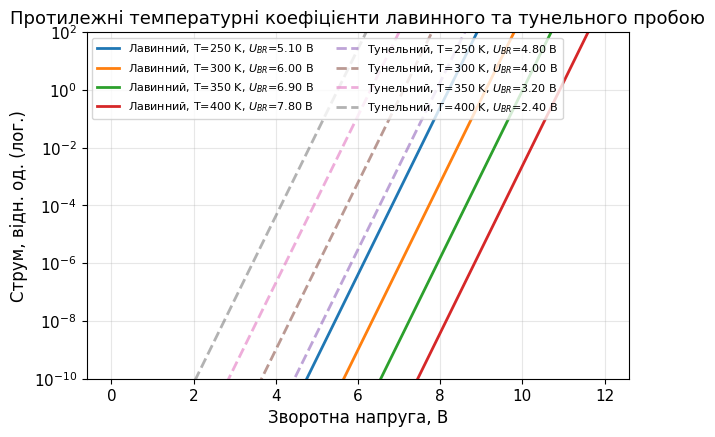

In [10]:
T_vals = [250, 300, 350, 400]  # К
U = np.linspace(0, 12, 400)

fig, ax = plt.subplots(figsize=(7,4.5))
for T in T_vals:
    UBR_avalanche = 6.0 * (1 + 0.003*(T-300))   # додатний ТКН
    I = 1e-9*np.exp((U-UBR_avalanche)/0.15)
    ax.semilogy(U, np.clip(I,1e-12,1e3), label=f'Лавинний, T={T} K, $U_{{BR}}$={UBR_avalanche:.2f} В')

for T in T_vals:
    UBR_tunnel = 4.0 * (1 - 0.004*(T-300))       # від'ємний ТКН
    I = 1e-9*np.exp((U-UBR_tunnel)/0.15)
    ax.semilogy(U, np.clip(I,1e-12,1e3), '--', alpha=0.6, label=f'Тунельний, T={T} K, $U_{{BR}}$={UBR_tunnel:.2f} В')

ax.set_xlabel('Зворотна напруга, В'); ax.set_ylabel('Струм, відн. од. (лог.)')
ax.set_title('Протилежні температурні коефіцієнти лавинного та тунельного пробою')
ax.legend(fontsize=8, ncol=2)
ax.set_ylim(1e-10, 1e2)
plt.show()

### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Легко переплутати, у якого механізму пробою який температурний коефіцієнт. Запам'ятайте зв'язок з напругою: **тунельний** пробій — це **низьковольтний** механізм (вузький перехід, сильне легування) з **від'ємним** ТКН; **лавинний** — **високовольтний** механізм (широкий перехід) з **додатним** ТКН. Саме тому стабілітрони з номінальною напругою близько 5–6 В, де обидва механізми діють одночасно і частково компенсують один одного, мають **найменший за модулем сумарний ТКН** і використовуються як прецизійні джерела опорної напруги.

</div>

### ✅ Питання для самоперевірки: Вольтамперна характеристика та пробій

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому в ідеальній моделі Шоклі зворотний струм не залежить від напруги, а в реальному діоді — залежить?</summary>

> **Відповідь:** Ідеальна модель враховує лише дифузійний струм неосновних носіїв з нейтральних областей, який дійсно від напруги не залежить. Реальний діод додатково має струм термогенерації в самому збідненому шарі, ширина якого зростає з напругою, тому реальний зворотний струм повільно збільшується.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Який фізичний параметр визначає, чи буде пробій даного p-n переходу тунельним чи лавинним?</summary>

> **Відповідь:** Рівень легування (а отже ширина переходу): сильне легування → вузький перехід → тунельний механізм за низької напруги; слабке/помірне легування → широкий перехід → лавинний механізм за вищої напруги.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому коефіцієнт неідеальності $n\approx2$ спостерігається саме при малих прямих струмах?</summary>

> **Відповідь:** При малих струмах (низька пряма напруга) переважає рекомбінаційний струм у самому збідненому шарі, що описується експонентою з $\varphi_T$, поділеним навпіл ($n=2$); при більших струмах домінує дифузійний струм Шоклі з $n=1$, поки не почне позначатися опір $R_s$.

</details>


### 🎯 Мета вивчення розділу: Типи напівпровідникових діодів

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати особливості та класифікацію випрямних діодів, наслідки їх послідовного й паралельного з'єднання
> - Пояснювати принцип дії, переваги й недоліки діодів Шотки порівняно зі звичайними p-n діодами
> - Пояснювати принцип дії, різновиди та застосування стабілітронів

</div>

# Випрямні діоди. Послідовне та паралельне включення <a class="anchor" id="rectifier-diodes"></a>

**Випрямні діоди** використовують різко несиметричну ВАХ p-n переходу (великий прямий струм, малий зворотний) для перетворення змінної напруги на пульсуючу однополярну. Основні параметри, за якими їх обирають: середній прямий струм $I_{пр.сер}$, максимальна допустима зворотна напруга $U_{зв.max}$ (або $U_{RRM}$), максимальний ударний (неповторюваний) струм $I_{FSM}$, час відновлення зворотного опору $t_{вв}$.

За потужністю розрізняють: маломожні (сигнальні, до ~1 А), середньої потужності та потужні силові діоди (десятки–сотні ампер, з фланцевими/штирьовими корпусами для кріплення до тепловідводу).

## Паралельне з'єднання діодів

Застосовують для збільшення допустимого прямого струму понад номінал одного приладу. Проблема — **експоненційний** характер прямої ВАХ: навіть невелика розбіжність прямого падіння напруги між "однаковими" за паспортом діодами (через розкид параметрів виробництва) призводить до **непропорційного** розподілу струму — діод з меншим падінням напруги бере на себе основну частку струму, сильніше нагрівається, що ще й знижує його падіння напруги (додатний тепловий зворотний зв'язок) — виникає ризик теплового руйнування ("виходу з рівноваги"). Для вирівнювання струмів застосовують додаткові вирівнюючі резистори (або дроселі) послідовно з кожним діодом, підбір діодів з одного виробничого партії, теплове з'єднання корпусів на спільному тепловідводі.

## Послідовне з'єднання діодів

Застосовують для збільшення допустимої зворотної напруги понад номінал одного приладу. Проблема — розкид **зворотних струмів витоку**: діод з меншим зворотним струмом (більшим зворотним опором) прийме на себе непропорційно **більшу частку** прикладеної зворотної напруги, що може перевищити його індивідуальний номінал і спричинити пробій саме цього діода, а після нього — лавиноподібний перерозподіл напруги на решту. Для вирівнювання застосовують **шунтуючі резистори** паралельно кожному діоду (статичне вирівнювання за струмом витоку) та **шунтуючі конденсатори** (динамічне вирівнювання під час перемикання, коли різні часи відновлення діодів також спричиняють нерівномірний розподіл перехідної напруги).

## Випрямляючі стовпи та блоки

**Випрямляючий стовп** — конструктивно єдиний виріб, що містить кілька послідовно з'єднаних діодних структур (кристалів) в одному корпусі, призначений для роботи при високих зворотних напругах (одиниці–десятки кіловольт), які неможливо забезпечити одним переходом; типово застосовуються у високовольтних джерелах живлення (рентгенівська апаратура, електронно-променеві прилади). **Випрямляючий блок** — модуль, що об'єднує кілька діодів у типовій схемній конфігурації (найчастіше — діодний міст) в одному корпусі з спільним тепловідводом, що спрощує монтаж і покращує тепловий режим порівняно з окремими діодами.

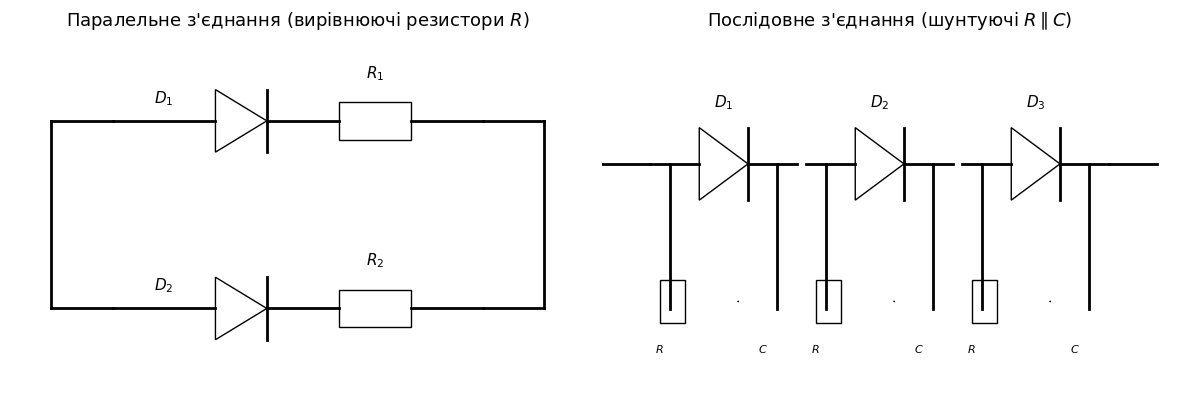

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# --- Паралельне з'єднання
ax = axes[0]
ax.set_title("Паралельне з'єднання (вирівнюючі резистори $R$)")
for i, y in enumerate([2.5, 1.0]):
    ax.plot([1,2],[y,y],'k-'); ax.text(1.5,y+0.15,f'$D_{i+1}$',ha='center')
    ax.add_patch(patches.Polygon([[2,y-0.25],[2,y+0.25],[2.5,y]], closed=True, facecolor='none', edgecolor='k'))
    ax.plot([2.5,2.5],[y-0.25,y+0.25],'k-')
    ax.plot([2.5,3.2],[y,y],'k-')
    ax.add_patch(patches.Rectangle((3.2,y-0.15),0.7,0.3, fill=False))
    ax.text(3.55,y+0.35,f'$R_{i+1}$',ha='center')
    ax.plot([3.9,4.6],[y,y],'k-')
ax.plot([0.4,1],[2.5,2.5],'k-'); ax.plot([0.4,1],[1.0,1.0],'k-'); ax.plot([0.4,0.4],[1.0,2.5],'k-')
ax.plot([4.6,5.2],[2.5,2.5],'k-'); ax.plot([4.6,5.2],[1.0,1.0],'k-'); ax.plot([5.2,5.2],[1.0,2.5],'k-')
ax.set_xlim(0,5.6); ax.set_ylim(0.3,3.2); ax.axis('off')

# --- Послідовне з'єднання
ax = axes[1]
ax.set_title(r"Послідовне з'єднання (шунтуючі $R \parallel C$)")
x0 = 0.5
for i in range(3):
    x = x0 + i*1.6
    ax.plot([x,x+0.5],[2,2],'k-')
    ax.add_patch(patches.Polygon([[x+0.5,1.75],[x+0.5,2.25],[x+1.0,2.0]], closed=True, facecolor='none', edgecolor='k'))
    ax.plot([x+1.0,x+1.0],[1.75,2.25],'k-')
    ax.plot([x+1.0,x+1.5],[2,2],'k-')
    ax.text(x+0.75, 2.4, f'$D_{i+1}$', ha='center')
    # shunt R||C below
    ax.plot([x+0.2,x+0.2],[2,1.0],'k-'); ax.plot([x+1.3,x+1.3],[2,1.0],'k-')
    ax.add_patch(patches.Rectangle((x+0.1,0.9),0.25,0.3, fill=False))
    ax.text(x+0.05, 0.7, '$R$', fontsize=8)
    ax.add_patch(patches.FancyArrow(x+0.9,1.05,0,0.001))
    ax.text(x+1.1, 0.7, '$C$', fontsize=8)
ax.plot([0.0,0.5],[2,2],'k-'); ax.plot([x+1.5, x+2.0],[2,2],'k-')
ax.set_xlim(0,x+2.2); ax.set_ylim(0.4,2.9); ax.axis('off')

plt.tight_layout(); plt.show()

### ⚡ Практичне застосування: Діодні мости в блочному виконанні

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Реальні мостові випрямлячі на схемах силової електроніки часто виконуються саме у вигляді готового **діодного блока** (наприклад, чотири діоди моста в одному корпусі з металевою основою для кріплення до радіатора) — це зменшує кількість з'єднань, покращує тепловідведення й гарантує узгодженість параметрів усіх плечей моста, підібраних виробником в межах одного технологічного процесу.

</div>

# Діоди з випрямним контактом метал-напівпровідник (діоди Шотки) <a class="anchor" id="schottky-diodes"></a>

На відміну від звичайного діода, побудованого на **p-n переході**, діод Шотки використовує випрямний контакт **метал – напівпровідник** (зазвичай метал, наприклад Al, Pt, PtSi, W, нанесений на слаболегований напівпровідник n-типу).

## Фізика бар'єра Шотки

Якщо робота виходу електрона з металу $\Phi_M$ перевищує роботу виходу з напівпровідника n-типу $\Phi_S$, то при контакті електрони перетікають з напівпровідника в метал доти, доки не вирівняються рівні Фермі. У напівпровіднику біля межі утворюється збіднений шар (шар нескомпенсованих іонів донорів) і потенціальний бар'єр — **бар'єр Шотки** $\varphi_B$ — аналогічний за формою бар'єру p-n переходу, але значно **нижчий** (типово 0.2–0.6 В залежно від пари метал/напівпровідник).

**Ключова фізична відмінність:** провідність визначається **основними носіями** (термоелектронна емісія електронів через бар'єр — механізм, відомий як **термоелектронна емісія Шотки**), тоді як у p-n діоді провідність визначається **інжекцією й дифузією неосновних носіїв**. Оскільки неосновні носії в структуру не інжектуються, у діода Шотки практично **відсутній ефект накопичення заряду** неосновних носіїв у базі.

## Переваги
- Значно **менший час відновлення зворотного опору** $t_{вв}$ (одиниці наносекунд і менше) — відсутнє розсмоктування неосновних носіїв, тому діод придатний для високочастотного випрямлення й швидкого перемикання;
- **Нижча пряма напруга** (0.15–0.45 В проти 0.6–0.7 В у кремнієвого p-n діода) завдяки нижчому бар'єру — менші втрати потужності при випрямленні великих струмів.

## Недоліки
- **Більший зворотний струм витоку**, що до того ж сильніше зростає з температурою і зворотною напругою (через ефект зниження бар'єра полем зображення — **Schottky barrier lowering**);
- **Нижча допустима зворотна напруга** порівняно зі звичайними p-n діодами тієї ж технології;
- Більша чутливість параметрів до якості технологічного процесу нанесення металевого контакту.

## Області застосування
Високочастотні детектори й змішувачі (історично — перші "кристалічні" детектори НВЧ), випрямлячі у імпульсних (ключових) джерелах живлення, діоди захисту від перенапруги в цифрових мікросхемах (Шотки-TTL логіка — запобігає насиченню транзистора), швидкодіючі перемикальні діоди, вихідні випрямлячі низьковольтних потужних перетворювачів.

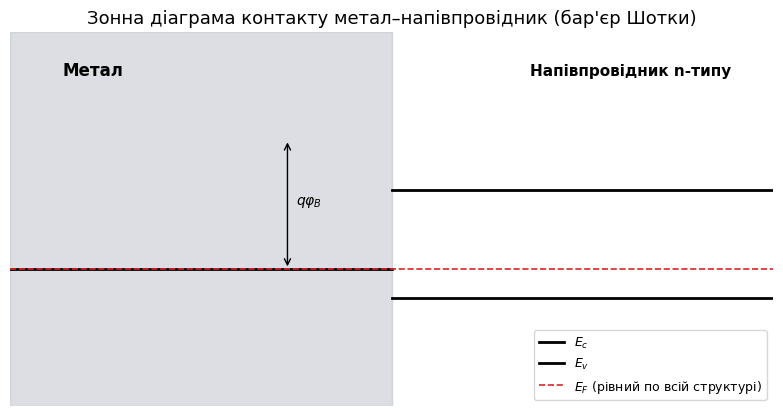

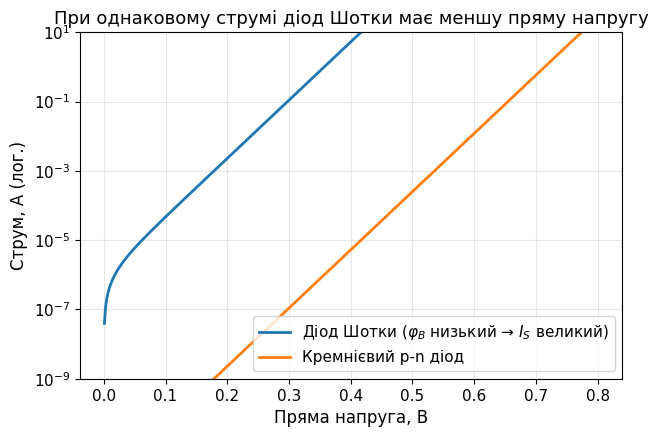

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.3))
xs = np.linspace(-2.2, 2.2, 400)
w_sb = 1.0
h_sb = 0.7
Ec = 3.0 + h_sb*np.clip(1-((xs+0.6)/w_sb)**2, 0, None)*(xs>-1.6)
Ec = np.where(xs < 0, 3.0 + h_sb*np.clip(1-((xs+1.0)/1.0)**2,0,None), 3.0)
Ev = Ec - 1.5

ax.axvspan(-2.2, 0, color='#9ca3af', alpha=0.35)
ax.text(-1.9, 4.6, 'Метал', fontsize=12, fontweight='bold')
ax.text(0.8, 4.6, 'Напівпровідник n-типу', fontsize=11, fontweight='bold')
ax.axhline(1.9, xmin=0.0, xmax=0.5, color='k', lw=2)
ax.plot(xs[xs>=0], Ec[xs>=0], color='k', lw=2, label='$E_c$')
ax.plot(xs[xs>=0], Ev[xs>=0], color='k', lw=2, label='$E_v$')
ax.axhline(1.9, color='#dc2626', ls='--', lw=1.2, label='$E_F$ (рівний по всій структурі)')
ax.annotate('', xy=(-0.6, 1.9), xytext=(-0.6, 3.0+h_sb), arrowprops=dict(arrowstyle='<->'))
ax.text(-0.55, (1.9+3.0+h_sb)/2, r'$q\varphi_B$', fontsize=10)
ax.set_xlim(-2.2, 2.2); ax.set_ylim(0, 5.2)
ax.axis('off')
ax.legend(loc='lower right', fontsize=9)
ax.set_title('Зонна діаграма контакту метал–напівпровідник (бар\'єр Шотки)')
plt.tight_layout(); plt.show()

# Порівняння форми прямої ВАХ: нижчий бар'єр Шотки => менший умовний Is_eff => менша пряма напруга при тому ж струмі
U = np.linspace(0.001, 0.8, 500)
Is_schottky = 1e-6   # набагато більший Is через нижчий бар'єр і термоемісійний механізм
Is_pn = 1e-12
I_sch = Is_schottky*(np.exp(U/phi_T)-1)
I_pn = Is_pn*(np.exp(U/phi_T)-1)

plt.figure(figsize=(7,4.5))
plt.semilogy(U, np.clip(I_sch,1e-15,None), label=r'Діод Шотки ($\varphi_B$ низький → $I_S$ великий)')
plt.semilogy(U, np.clip(I_pn,1e-15,None), label='Кремнієвий p-n діод')
plt.xlabel('Пряма напруга, В'); plt.ylabel('Струм, А (лог.)')
plt.title('При однаковому струмі діод Шотки має меншу пряму напругу')
plt.ylim(1e-9, 10); plt.legend()
plt.show()

# Стабілітрони <a class="anchor" id="zener-diodes"></a>

**Стабілітрон** — це напівпровідниковий діод, спеціально сконструйований (за рахунок підвищеного й точно контрольованого рівня легування) для роботи саме в режимі **зворотного електричного пробою**, причому пробій є **оборотним**: за умови обмеження струму й розсіюваної потужності прилад витримує тривалу роботу в цьому режимі без деградації.

## Механізм пробою і напруга стабілізації

Як розглянуто вище: за $U_{ст} \lesssim 5$–$6$ В домінує **тунельний** механізм, за $U_{ст}\gtrsim 6$–$7$ В — **лавинний**; у проміжній зоні діють обидва одночасно з майже протилежними температурними коефіцієнтами, тому стабілітрони на ~5.6 В мають найменший ТКН. ВАХ характеризується різким "коліном" при $U_{ст}$, за яким струм зростає практично вертикально.

## Основні параметри

- **Номінальна напруга стабілізації** $U_{ст}$ при заданому струмі $I_{ст}$;
- **Диференціальний (динамічний) опір** $r_{ст}=dU/dI$ у робочій точці — чим менший, тим стабільніша напруга при зміні струму навантаження;
- Мінімальний струм стабілізації $I_{ст.min}$ (нижче "коліна" стабілізація ще нестійка) і максимальний $I_{ст.max}$, обмежений допустимою потужністю розсіювання $P_{max}$;
- **Температурний коефіцієнт напруги** (ТКН, %/°C).

## Різновиди

- **Одинарні (однобічні) стабілітрони** — базовий тип, номінали від ~1.8 В до кількох сотень вольт;
- **Двоанодні (симетричні, двосторонні) стабілітрони** — два стабілітрони, з'єднані назустріч один одному в одному корпусі; забезпечують симетричне обмеження напруги в обидва півперіоди змінного сигналу;
- **Прецизійні (термокомпенсовані) стабілітрони** — стабілітрон послідовно з'єднаний зі звичайним прямозміщеним діодом, температурний коефіцієнт якого (завжди від'ємний) компенсує залишковий ТКН стабілітрона — застосовуються як точні джерела опорної напруги;
- **Стабілітрони — обмежувачі перенапруг (TVS-подібні)** — конструктивно оптимізовані для поглинання короткочасних потужних імпульсів (більша площа переходу, розрахована радіатором розсіювання енергії) без пробою за амплітудою; використовуються для захисту від сплесків напруги.

## Області застосування

Параметричні стабілізатори опорної напруги (найпростіша схема — стабілітрон і баластний резистор, живлені від нестабілізованого джерела), формування опорних рівнів у аналогових і цифрових схемах, обмеження (кліпування) амплітуди сигналів, захист входів від перевищення напруги живлення й статичної електрики.

### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Стабілітрон названо на честь фізика **Кларенса Зенера**, який 1934 року теоретично описав саме тунельний механізм пробою діелектрика в сильному електричному полі. Проте більшість сучасних "стабілітронів" з номінальною напругою вище ~5.5–6 В насправді працюють через **лавинний**, а не зенерівський (тунельний) механізм — історична назва компонента збереглася, хоча описує лише частину реально задіяної фізики.

</div>

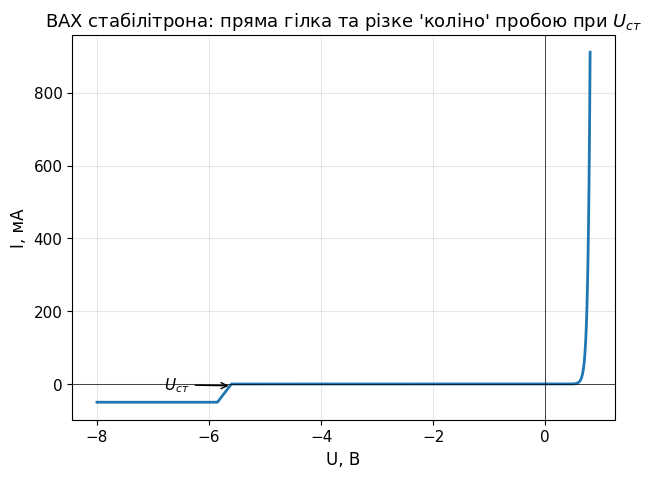

interactive(children=(FloatSlider(value=5.6, description='$U_z$, В', max=15.0, min=2.0), FloatSlider(value=5.0…

In [13]:
def zener_iv(U, Vz=5.6, rz=5.0, Is=1e-9, n=1.5, Imax=0.05):
    I = np.where(U > -0.1,
                 Is*(np.exp(U/(n*phi_T))-1),
                 -(np.clip((-U-Vz),0,None)/rz + 1e-6))
    return np.clip(I, -Imax, 1.0)

U = np.linspace(-8, 0.8, 900)
I = zener_iv(U)

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(U, I*1e3)
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('U, В'); ax.set_ylabel('I, мА')
ax.set_title("ВАХ стабілітрона: пряма гілка та різке 'коліно' пробою при $U_{ст}$")
ax.annotate('$U_{ст}$', xy=(-5.6, -5), xytext=(-6.8, -15), arrowprops=dict(arrowstyle='->'))
plt.show()

def plot_zener(Vz=5.6, rz=5.0):
    U_ = np.linspace(-Vz-3, 0.8, 900)
    I_ = zener_iv(U_, Vz=Vz, rz=rz)
    plt.figure(figsize=(6,4.2))
    plt.plot(U_, I_*1e3)
    plt.axhline(0, color='k', lw=0.5); plt.axvline(0, color='k', lw=0.5)
    plt.xlabel('U, В'); plt.ylabel('I, мА')
    plt.title(f'$U_z$={Vz:.1f} В, $r_z$={rz:.1f} Ом')
    plt.show()

w = interactive(plot_zener,
                 Vz=widgets.FloatSlider(value=5.6, min=2.0, max=15.0, step=0.1, description='$U_z$, В'),
                 rz=widgets.FloatSlider(value=5.0, min=1.0, max=30.0, step=1.0, description='$r_z$, Ом'))
display(w)

### ⚡ Практичне застосування: Параметричний стабілізатор напруги

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Найпростіший параметричний стабілізатор напруги**: нестабілізоване джерело $E$ підключають до навантаження через баластний резистор $R_б$, а стабілітрон вмикають паралельно навантаженню в зворотному напрямку. Поки струм через стабілітрон лишається в межах $[I_{ст.min}, I_{ст.max}]$, напруга на навантаженні дорівнює $U_{ст}$ й майже не залежить ані від коливань $E$, ані від зміни струму навантаження — завдяки малому диференціальному опору $r_{ст}$ в робочій точці.

</div>

2026-09-21 10:53:17,366 - PySpice.Spice.Netlist.Node.__init__ - WARNING - Node name 'in' is a Python keyword


2026-09-21 10:53:17,369 - PySpice.Spice.NgSpice.Shared.NgSpiceShared._send_char - WARNING - Using SPARSE 1.3 as Direct Linear Solver


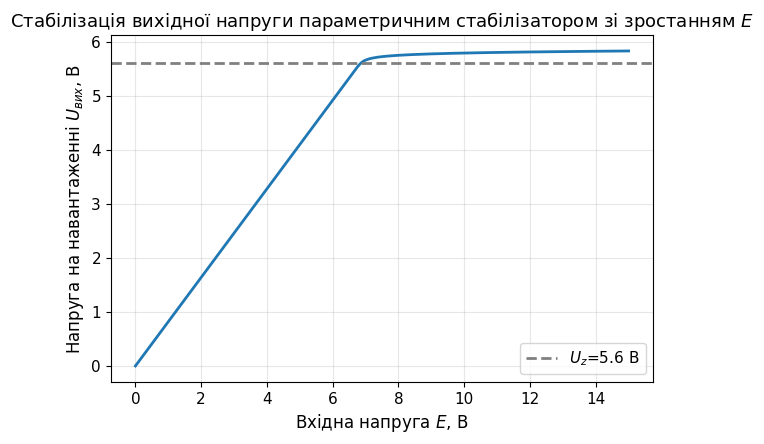

In [14]:
circuit = Circuit('Zener shunt regulator')
circuit.V('in', 'in', circuit.gnd, 12@u_V)
circuit.R('b', 'in', 'out', 220@u_Ohm)
circuit.model('DZ', 'D', IS=1e-10, N=1.5, BV=5.6, IBV=1e-4)
circuit.D('Z1', circuit.gnd, 'out', model='DZ')   # анод на землі -> зворотне включення відносно out
circuit.R('load', 'out', circuit.gnd, 1@u_kOhm)

simulator = circuit.simulator(temperature=25, nominal_temperature=25)
analysis = simulator.dc(Vin=slice(0, 15, 0.05))

Uin = np.array(analysis.sweep)
Uout = np.array(analysis['out'])

plt.figure(figsize=(7,4.5))
plt.plot(Uin, Uout)
plt.axhline(5.6, color='gray', ls='--', label='$U_z$=5.6 В')
plt.xlabel('Вхідна напруга $E$, В'); plt.ylabel('Напруга на навантаженні $U_{вих}$, В')
plt.title('Стабілізація вихідної напруги параметричним стабілізатором зі зростанням $E$')
plt.legend(); plt.show()

### ✅ Питання для самоперевірки: Типи діодів

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому при паралельному з'єднанні випрямних діодів потрібні вирівнюючі резистори, а при послідовному — вирівнюючі резистори і конденсатори?</summary>

> **Відповідь:** При паралельному з'єднанні небезпечна нерівномірність прямого струму через розкид прямої напруги (експоненційна залежність) — вирівнюючі резистори (лінійний елемент) зменшують цю чутливість. При послідовному з'єднанні небезпечна нерівномірність зворотної напруги через розкид зворотних струмів витоку (шунтуючі резистори — статичне вирівнювання) та розкид часу відновлення при перемиканні (шунтуючі конденсатори — динамічне вирівнювання перехідної напруги).

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому діод Шотки перемикається значно швидше за звичайний p-n діод?</summary>

> **Відповідь:** Провідність діода Шотки визначається лише основними носіями (термоелектронна емісія через бар'єр), тому в базі не накопичується заряд неосновних носіїв, який довелося б розсмоктувати при вимкненні. У p-n діода саме розсмоктування інжектованого заряду неосновних носіїв і визначає час відновлення зворотного опору.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому стабілітрони з номінальною напругою близько 5–6 В мають найменший температурний дрейф?</summary>

> **Відповідь:** У цьому діапазоні одночасно діють тунельний механізм (від'ємний ТКН) і лавинний механізм (додатний ТКН) пробою; їхні протилежні за знаком внески частково компенсують один одного, зменшуючи сумарну температурну залежність напруги стабілізації.

</details>


---

## 📌 Підсумок частини 1: Основи теорії та напівпровідникові діоди

<div style="background-color: #f0fdf4; padding: 24px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

### Зведена таблиця механізмів пробою p-n переходу

| Механізм | Легування / ширина переходу | Типова $U_{BR}$ | ТКН | Застосування |
|---|---|---|---|---|
| **Тунельний (зенерівський)** | Сильне, вузький перехід | до ~5–6 В | від'ємний | низьковольтні стабілітрони, тунельні діоди |
| **Лавинний** | Помірне/слабке, широкий перехід | > 6–7 В | додатний | стабілітрони >6–7 В, лавинні фотодіоди, граничні напруги випрямних діодів |

### Порівняння типів діодів

| Тип | Механізм провідності | Пряма напруга | Швидкодія | Типове застосування |
|---|---|---|---|---|
| **Випрямний p-n** | Дифузія/інжекція неосновних носіїв | ~0.6–0.7 В (Si) | помірна | випрямлення мережевої напруги |
| **Шотки** | Термоемісія основних носіїв через бар'єр метал–НП | ~0.15–0.45 В | висока | ВЧ-випрямлення, ключові джерела живлення |
| **Стабілітрон** | Керований зворотний пробій (тунель/лавина) | пряма — як у звичайного; робочий режим — зворотний пробій | — | стабілізація й обмеження напруги |

### Ключове рівняння курсу — рівняння Шоклі

$$I = I_S\left(\exp\frac{U}{n\varphi_T}-1\right)$$

Це рівняння — фундамент для розуміння роботи *будь-якого* p-n переходу, включно з переходами біполярного транзистора, який розглядається у **частині 2**.

</div>

---

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*